In [58]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import joblib
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import classification_report,confusion_matrix
import matplotlib.pyplot as plt
import  seaborn as sns


step 1:load the employee attrition dataset

In [59]:
df = pd.read_csv(r"C:\Users\BN SAHARA\OneDrive\Documents\Project real time\Attrition project1\HR Employee Attrition.csv")
print(df.shape)
print(df["Attrition"].value_counts(normalize=True))

(1470, 35)
Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64


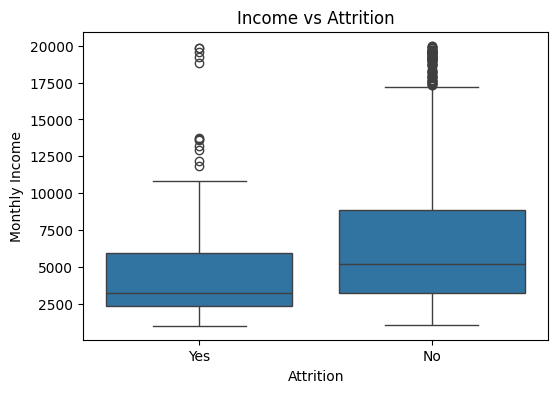

In [60]:
plt.figure(figsize=(6, 4))
sns.boxplot(x="Attrition",y="MonthlyIncome", data=df)
plt.title("Income vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

step 2:perform eda

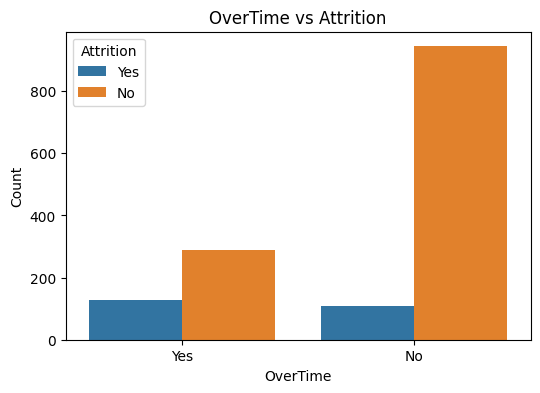

In [61]:
#income vs attrition

plt.figure(figsize=(6,4))
sns.countplot(x="OverTime",hue="Attrition",data=df)
plt.title("OverTime vs Attrition")
plt.xlabel("OverTime")
plt.ylabel("Count")
plt.legend(title="Attrition")
plt.show()

In [ ]:
#drop irrelevent columns
df.drop(["EmployeeNumber", "EmployeeCount", "Over18", "StandardHours"], axis=1, inplace=True)

#Encoder categorical variables
#lb=LabelEncoder()
encoder={}
for col in df.select_dtypes(include=["object"]).columns:
    lb=LabelEncoder()
    df[col]=lb.fit_transform(df[col])

#split data into features and target
x = df.drop("Attrition", axis=1)
y=df["Attrition"]

#split data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.4, random_state=42)

C:\Users\BN SAHARA\AppData\Local\Temp\ipykernel_22264\2651539004.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=["object"]).columns:


step 4:Modelling and Tunning

In [ ]:
#Define the model
rf=RandomForestClassifier(random_state=42)

#Hyperparameters tuning
param_grid = {
"n_estimators": [50, 100],
"max_depth": [10, 20, None],
"min_samples_split": [2, 5],
"min_samples_leaf" :[1, 2],
}

grid_search=GridSearchCV(rf, param_grid, cv=5, scoring='f1')
grid_search.fit(x_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)

Best Hyperparameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


step 5:evalute the model

              precision    recall  f1-score   support

           0       0.88      0.99      0.93       507
           1       0.81      0.16      0.27        81

    accuracy                           0.88       588
   macro avg       0.85      0.58      0.60       588
weighted avg       0.87      0.88      0.84       588

[[504   3]
 [ 68  13]]


Text(0, 0.5, 'Feature')

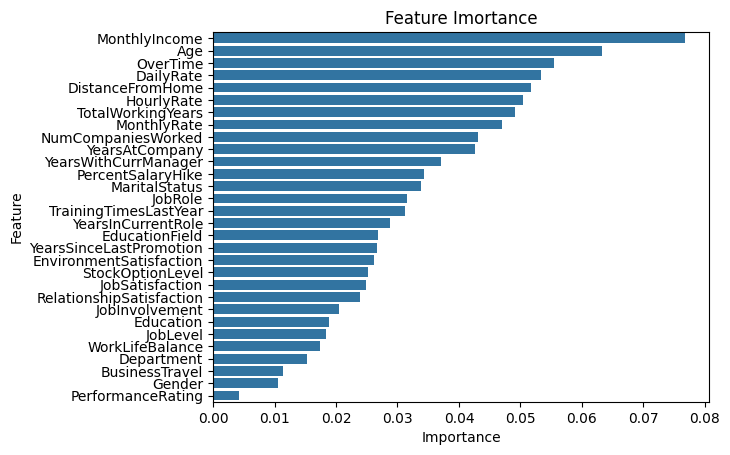

In [71]:
best_model=grid_search.best_estimator_
predictions=best_model.predict(x_test)

print(classification_report(y_test, predictions))
print(confusion_matrix(y_test, predictions))

importances=best_model.feature_importances_
feature_importance_df=pd.DataFrame({
    "Feature": x.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)
plt.Figure(figsize=(12, 8))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df)
plt.title("Feature Imortance")
plt.xlabel("Importance")
plt.ylabel("Feature")

step 6: saving the model

In [68]:
model = RandomForestClassifier(**grid_search.best_params_, random_state=42)
model.fit(x, y)

#save the model
joblib.dump(model, "employee_attrition.pkl")
joblib.dump(lb, "label_encoder.pkl")
joblib.dump(x.columns.to_list(), "feature_columns.pkl")

['feature_columns.pkl']